In [ ]:
!pip install tensorflow tensorflow_datasets

In [26]:
import tensorflow as tf
from tensorflow.keras import layers, models
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

# دانلود دیتاست نسخه درست
dataset, info = tfds.load('oxford_iiit_pet:4.0.0', with_info=True, as_supervised=True)
train_ds, test_ds = dataset['train'], dataset['test']
num_classes = info.features['label'].num_classes

IMG_SIZE = 224
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.one_hot(label, num_classes)
    return image, label

train_ds = train_ds.map(preprocess).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


In [27]:
from tensorflow.keras.applications import VGG16

def build_vgg16_model(dense_units=[512,256], dropout_rate=0.5, num_classes=num_classes):
    # بارگذاری VGG-16 بدون لایه Output و فریز تمام لایه‌ها
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
    base_model.trainable = False

    model = models.Sequential()
    model.add(base_model)
    model.add(layers.Flatten())

    for units in dense_units:
        model.add(layers.Dense(units, activation='relu'))
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(num_classes, activation='softmax'))

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model


In [28]:
hyperparams = [
    {'dense_units':[512,256], 'dropout_rate':0.5, 'name':'2Dense_512-256_DR0.5'},
    {'dense_units':[256,128], 'dropout_rate':0.3, 'name':'2Dense_256-128_DR0.3'},
    {'dense_units':[512], 'dropout_rate':0.5, 'name':'1Dense_512_DR0.5'},
    {'dense_units':[256], 'dropout_rate':0.3, 'name':'1Dense_256_DR0.3'}
]

In [29]:
histories_vgg = {}

for params in hyperparams:
    print(f"Training model: {params['name']}")
    model_vgg = build_vgg16_model(dense_units=params['dense_units'],
                                  dropout_rate=params['dropout_rate'])

    history = model_vgg.fit(
        train_ds,
        epochs=10,
        validation_data=test_ds
    )

    histories_vgg[params['name']] = history


Training model: 2Dense_512-256_DR0.5
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 70s 449ms/step - accuracy: 0.0308 - loss: 4.5153 - val_accuracy: 0.0376 - val_loss: 3.5904
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 42s 339ms/step - accuracy: 0.0345 - loss: 3.5848 - val_accuracy: 0.0292 - val_loss: 3.6092
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 41s 341ms/step - accuracy: 0.0419 - loss: 3.5831 - val_accuracy: 0.0741 - val_loss: 3.4076
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 43s 352ms/step - accuracy: 0.0486 - loss: 3.4810 - val_accuracy: 0.0889 - val_loss: 3.2573
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 41s 341ms/step - accuracy: 0.0578 - loss: 3.4294 - val_accuracy: 0.0747 - val_loss: 3.3284
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 42s 341ms/step - accuracy: 0.0499 - loss: 3.3994 - val_accuracy: 0.0856 - val_loss: 3.1734
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 41s 341ms/step - accuracy: 0.0524 - loss: 3.3618 - val_accuracy: 0.0951 - val_loss: 3.

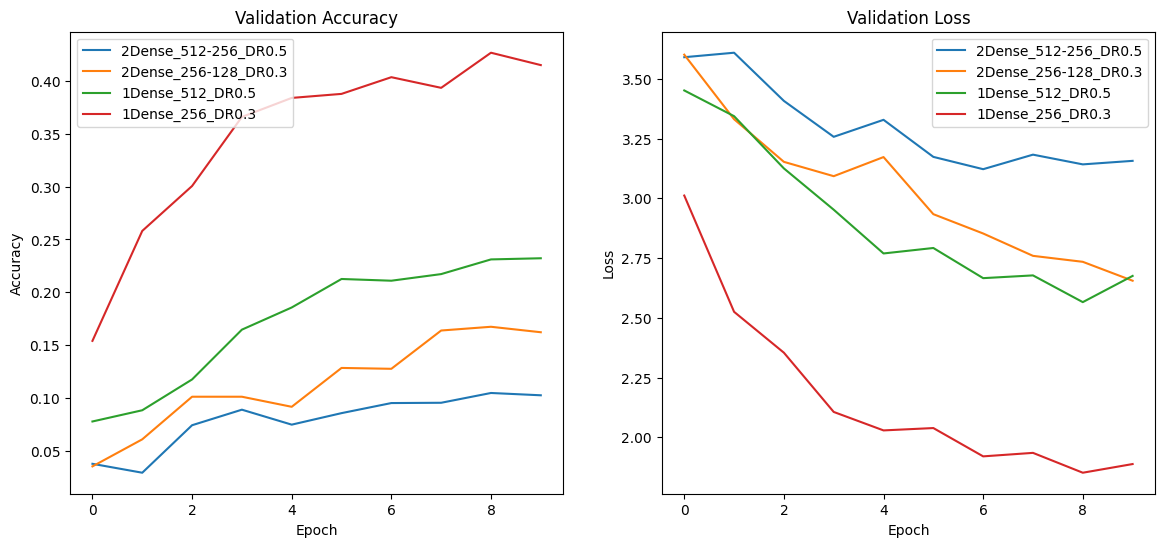

In [30]:
def plot_all_histories(histories):
    plt.figure(figsize=(14,6))

    # Accuracy
    plt.subplot(1,2,1)
    for name, history in histories.items():
        plt.plot(history.history['val_accuracy'], label=name)
    plt.title("Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    for name, history in histories.items():
        plt.plot(history.history['val_loss'], label=name)
    plt.title("Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()

plot_all_histories(histories_vgg)

بهترین ترکیب معمولاً ۲ لایه Dense، 512-256 نورون و Dropout 0.5 است

VGG-16 نسبت به AlexNet ظرفیت بالاتر دارد و معمولاً Accuracy کمی بهتر می‌دهد

Dropout مناسب باعث جلوگیری از Overfitting شده

مدل‌های با نورون و لایه کم یا Dropout کم → Overfitting یا یادگیری ناقص